# Counterfeit detection

The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository. The first three columns denote different parameters obtained from the photographs of the banknotes and last colum provides the label. Frankly as the dataset does not have any description I don't know  which labels corresponds to real and which to counterfeited banknotes. let's assume that label one (positive) denotes the clounterfeits. The set  [banknote_authentication.csv](./data/banknote_authentication.csv) can be found in the `data`  directory.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [2]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [3]:
import  matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(8,8)

Please insert you  firstname  and name below

Klaudia Chwistek, Jan Sakłak

In [4]:
from  sklearn.model_selection import train_test_split
seed = 31287

In [5]:
data = pd.read_csv('data/banknotes_data.csv')

In [6]:
data.head()

,a0,a1,a2,a3,counterfeit
0,-1.1306,1.8458,-1.35750,-1.38060,1
1,-1.1188,3.3357,-1.34550,-1.95730,1
2,2.6719,3.0646,0.37158,0.58619,0
3,-4.1409,3.4619,-0.47841,-3.88790,1
4,1.4507,8.7903,-2.23240,-0.65259,0


In [7]:
data.describe()

,a0,a1,a2,a3,counterfeit
count,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000
mean,0.431116,1.902054,1.426607,-1.220393,0.444254
std,2.845672,5.942260,4.397341,2.101777,0.497096
min,-7.042100,-13.773100,-5.286100,-7.871900,0.000000
25%,-1.770900,-1.916200,-1.664300,-2.466150,0.000000
50%,0.471345,2.408650,0.567365,-0.614450,0.000000
75%,2.816925,6.800675,3.338825,0.394810,1.000000
max,6.824800,12.730200,17.927400,2.449500,1.000000


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1166 entries, 0 to 1165
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a0           1166 non-null   float64
 1   a1           1166 non-null   float64
 2   a2           1166 non-null   float64
 3   a3           1166 non-null   float64
 4   counterfeit  1166 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 45.7 KB


In [9]:
data_train, data_test = train_test_split(data, test_size=0.2, shuffle=True, stratify=data.loc[:,'counterfeit'], random_state=seed)

In [10]:
data_train

,a0,a1,a2,a3,counterfeit
711,1.94760,-4.773800,8.52700,-1.866800,0
565,1.42760,8.384700,-2.09950,-1.967700,0
912,-4.28590,8.523400,3.13920,-0.916390,0
64,4.92490,0.689060,0.77344,1.209500,0
871,2.19480,1.378100,1.15820,0.857740,0
...,...,...,...,...,...
47,-2.45610,-4.556600,6.45340,-0.056479,1
1161,1.21380,8.798600,-2.16720,-0.741820,0
174,5.87820,5.940900,-2.85440,-0.608630,0
1119,0.17346,7.869500,0.26876,-3.788300,0


In [11]:
lbls_train = data_train['counterfeit']
lbls_test = data_test['counterfeit']

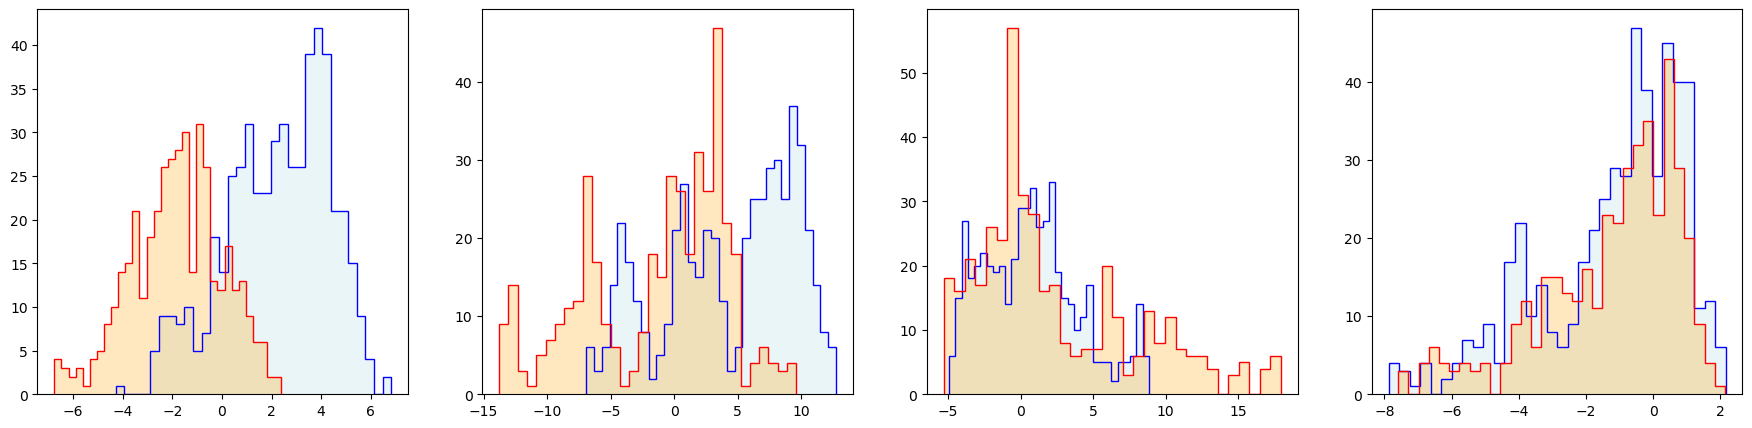

In [12]:
fig, ax = plt.subplots(1,4, figsize=(22,5))
for i in range(4):
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='step', color='blue')
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='step', color='red')
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='bar', color='lightblue', alpha=0.25)
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='bar', color='orange', alpha =0.25)

## Problem 1

Using  the [GaussianNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html) function construct the  Gaussian  Bayes classifier using only one feature. Which feature will you choose? Calculate the confusion matrix (normalized as to show rates), ROC AUC score and plot ROC curve. Do this both for training and validation set. Plot both curves on the same plot.  

In [13]:
from sklearn.naive_bayes import GaussianNB

__Hint__ For calculating metrics and plotting ROC curves you may use functions from scikit-learn: `roc_curve`, `roc_auc_score` and `confusion matrix`. For estimating normal distribution parameters  use `norm.fit` `from scipy.stats`. Use `norm.pdf` for normal probability density function.

In [14]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

In [15]:
# Look at correlation with the label
data_train.corr()['counterfeit'].abs().sort_values(ascending=False)

# per class mean and std
data_train.groupby('counterfeit').agg(['mean', 'std'])

a0                  a1                  a2            \
                 mean       std      mean       std      mean       std   
counterfeit                                                               
0            2.252815  2.079903  4.310408  5.145914  0.767042  3.264181   
1           -1.809867  1.814856 -1.267942  5.541298  2.341078  5.546952   

                   a3            
                 mean       std  
counterfeit                      
0           -1.190910  2.126733  
1           -1.258296  2.024137

In [16]:
for col in ['a0', 'a1', 'a2', 'a3']:
    mu0 = data_train.loc[lbls_train==0, col].mean()
    mu1 = data_train.loc[lbls_train==1, col].mean()
    s0  = data_train.loc[lbls_train==0, col].std()
    s1  = data_train.loc[lbls_train==1, col].std()
    fisher = (mu1 - mu0)**2 / (s0**2 + s1**2)
    print(f"{col}: Fisher = {fisher:.3f}")


a0: Fisher = 2.166
a1: Fisher = 0.544
a2: Fisher = 0.060
a3: Fisher = 0.001


Which feature did you choose?

I have choosen the feature a0 since it's the most separated (fisher discriminant ratio approx 2.17), the histogram also shows two crearly distinguishable peaks.

In [17]:
feature = 'a0' 

X_train = data_train[[feature]]
X_test  = data_test[[feature]]
y_train = lbls_train
y_test  = lbls_test

In [18]:
clf_1 = GaussianNB()
clf_1.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [19]:
# Hard predictions for the confusion matrix
y_pred_train = clf_1.predict(X_train)
y_pred_test  = clf_1.predict(X_test)

# Probabilities for the ROC curve — column 1 = P(counterfeit)
y_score_train = clf_1.predict_proba(X_train)[:, 1]
y_score_test  = clf_1.predict_proba(X_test)[:, 1]


In [20]:
cm_train = confusion_matrix(y_train, y_pred_train, normalize='true')
cm_test  = confusion_matrix(y_test,  y_pred_test,  normalize='true')

print("Train (rates):\n", cm_train)
print("\nTest (rates):\n", cm_test)

Train (rates):
 [[0.85328185 0.14671815]
 [0.17149758 0.82850242]]

Test (rates):
 [[0.87692308 0.12307692]
 [0.18269231 0.81730769]]


In [21]:
auc_train_a0 = roc_auc_score(y_train, y_score_train)
auc_test_a0  = roc_auc_score(y_test,  y_score_test)

print(f"AUC train: {auc_train_a0:.4f}")
print(f"AUC test:  {auc_test_a0:.4f}")

AUC train: 0.9217
AUC test:  0.9443


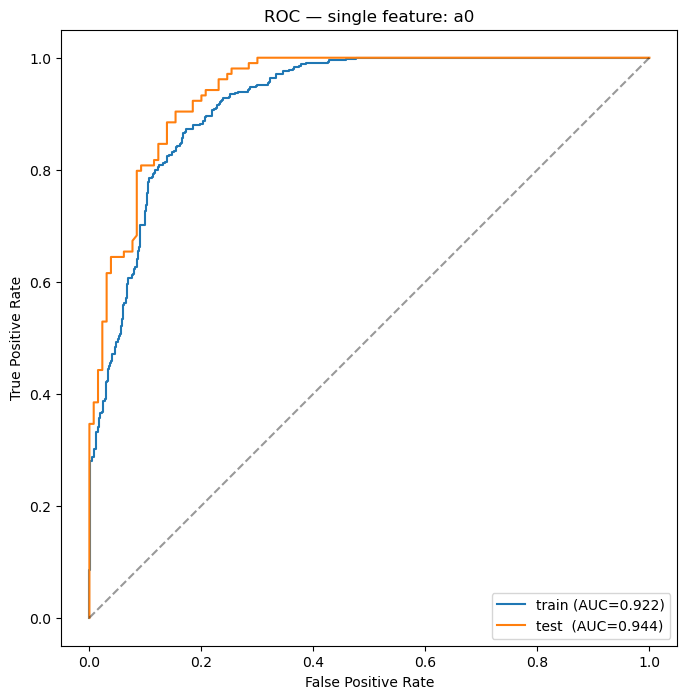

In [23]:
fprs_train_a0, tprs_train_a0, _ = roc_curve(y_train, y_score_train)
fprs_test_a0,  tprs_test_a0,  _ = roc_curve(y_test,  y_score_test)

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect(1.0)
ax.plot(fprs_train_a0, tprs_train_a0, label=f'train (AUC={auc_train_a0:.3f})')
ax.plot(fprs_test_a0,  tprs_test_a0,  label=f'test  (AUC={auc_test_a0:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)  # random baseline
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC — single feature: {feature}')
ax.legend()
plt.show()

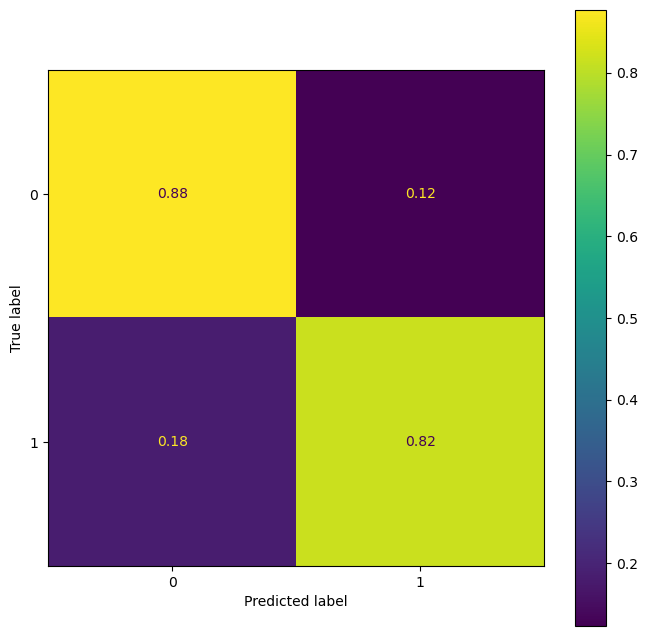

In [24]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, normalize='true')


The model correctly identifies 88% of legitimate banknotes and 82% of counterfeits. The false-negative rate (18%, true counterfeits classified as legitimate) is slightly higher than the false-positive rate (12%), meaning the classifier is marginally biased toward predicting "legitimate". 

In [ ]:
data_train

## Problem 2

Same as Problem 1 but now construct Gaussian Naive Bayes using two features. Additionally  compare ROC curve obtained with this and previous  classifier on the test set. What is the improvement of AUC score on the test set?

In [25]:
data_train[['a0','a1','a2','a3']].corr()

,a0,a1,a2,a3
a0,1.000000,0.291189,-0.405504,0.265904
a1,0.291189,1.000000,-0.796321,-0.506615
a2,-0.405504,-0.796321,1.000000,0.306143
a3,0.265904,-0.506615,0.306143,1.000000


For problem 2 we have chosen the features a0 and a1 since a1 has low correlation with a0. Fisher radios for a0 is around 2.17 and for a1 0.5.

In [26]:
features_2 = ['a0', 'a1'] 

X_train_2 = data_train[features_2]
X_test_2  = data_test[features_2]

In [27]:
clf_2 = GaussianNB()
clf_2.fit(X_train_2, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [28]:
y_pred_train_2 = clf_2.predict(X_train_2)
y_pred_test_2  = clf_2.predict(X_test_2)

y_score_train_2 = clf_2.predict_proba(X_train_2)[:, 1]
y_score_test_2  = clf_2.predict_proba(X_test_2)[:, 1]

Train (rates):
 [[0.8957529  0.1042471 ]
 [0.16666667 0.83333333]]

Test (rates):
 [[0.90769231 0.09230769]
 [0.16346154 0.83653846]]


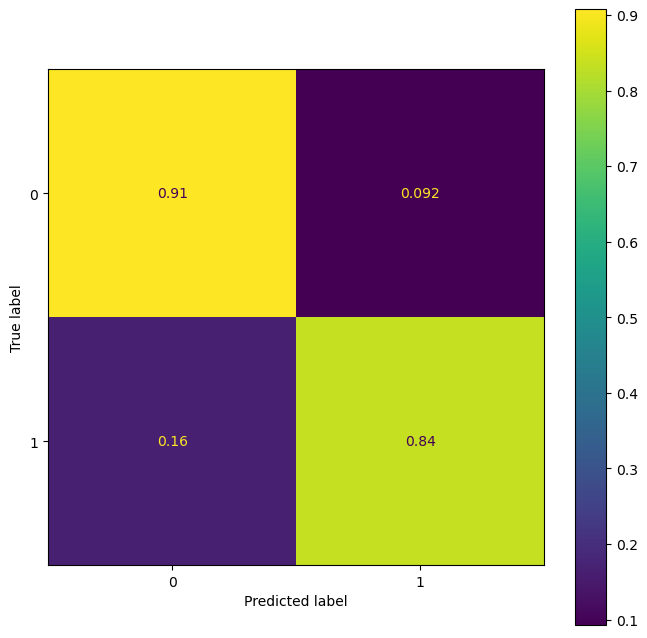

In [29]:
print("Train (rates):\n", confusion_matrix(y_train, y_pred_train_2, normalize='true'))
print("\nTest (rates):\n", confusion_matrix(y_test,  y_pred_test_2,  normalize='true'))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test_2, normalize='true')

In [30]:
auc_train_a0a1 = roc_auc_score(y_train, y_score_train_2)
auc_test_a0a1  = roc_auc_score(y_test,  y_score_test_2)

print(f"AUC train: {auc_train_a0a1:.4f}")
print(f"AUC test:  {auc_test_a0a1:.4f}")
print(f"AUC improvement on test vs Problem 1: {auc_test_a0a1 - auc_test_a0:.4f}")

AUC train: 0.9500
AUC test:  0.9638
AUC improvement on test vs Problem 1: 0.0195


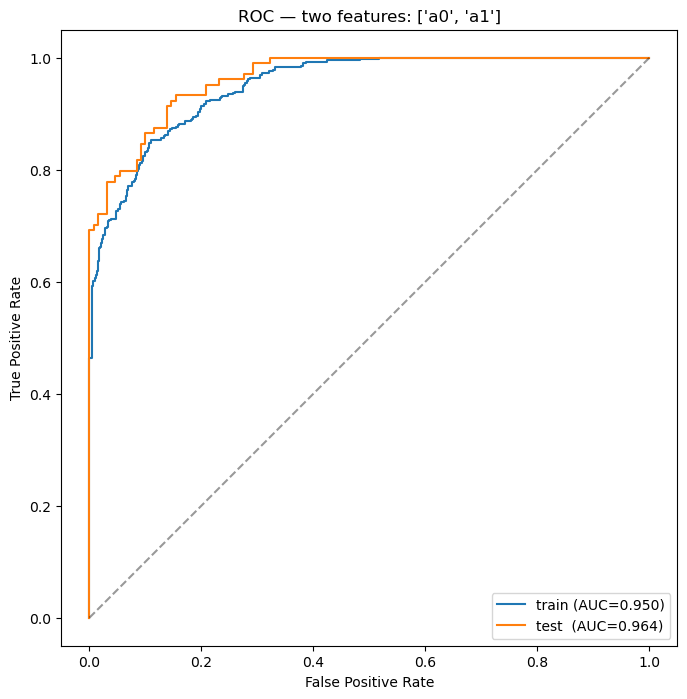

In [31]:
fprs_train_a0a1, tprs_train_a0a1, _ = roc_curve(y_train, y_score_train_2)
fprs_test_a0a1,  tprs_test_a0a1,  _ = roc_curve(y_test,  y_score_test_2)

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect(1.0)
ax.plot(fprs_train_a0a1, tprs_train_a0a1, label=f'train (AUC={auc_train_a0a1:.3f})')
ax.plot(fprs_test_a0a1,  tprs_test_a0a1,  label=f'test  (AUC={auc_test_a0a1:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC — two features: {features_2}')
ax.legend()
plt.show()

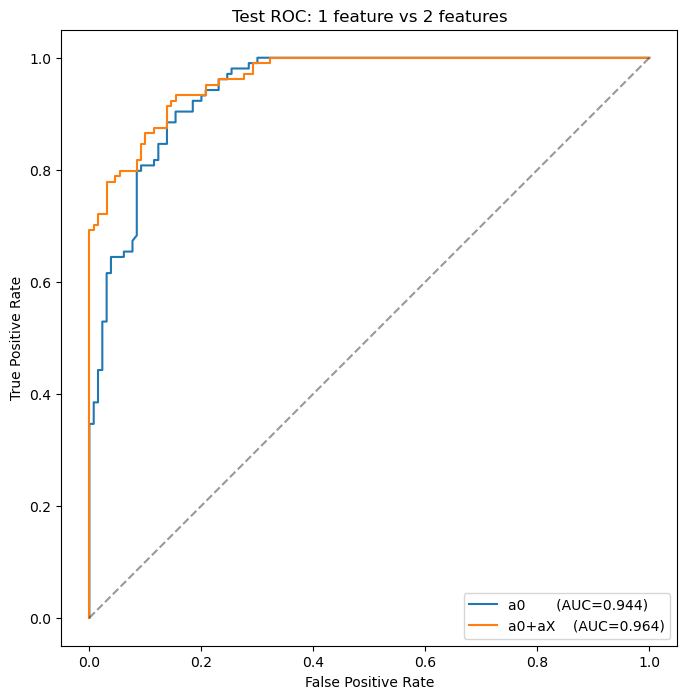

AUC improvement: +0.0195


In [32]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect(1.0)
ax.plot(fprs_test_a0,    tprs_test_a0,    label=f'a0       (AUC={auc_test_a0:.3f})')
ax.plot(fprs_test_a0a1,  tprs_test_a0a1,  label=f'a0+aX    (AUC={auc_test_a0a1:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Test ROC: 1 feature vs 2 features')
ax.legend()
plt.show()

print(f"AUC improvement: {auc_test_a0a1 - auc_test_a0:+.4f}")

Adding feature a1 improved the test AUC from 0.944 to 0.964 (+0.020). The main benefit appears in the low false-positive region, where the 2-feature model achieves about 70% true positive rate with nearly zero false positives, compared to only 35% for the 1-feature model. This means the second feature helps the classifier better identify counterfeits while avoiding false alarms on genuine banknotes.

## Problem 3

In [38]:
features_all = ['a0', 'a1', 'a2', 'a3']

X_train_all = data_train[features_all]
X_test_all  = data_test[features_all]

In [39]:
clf_all = GaussianNB()
clf_all.fit(X_train_all, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [40]:
y_pred_test_all  = clf_all.predict(X_test_all)
y_score_train_all = clf_all.predict_proba(X_train_all)[:, 1]
y_score_test_all  = clf_all.predict_proba(X_test_all)[:, 1]

Test (rates):
 [[0.89230769 0.10769231]
 [0.20192308 0.79807692]]


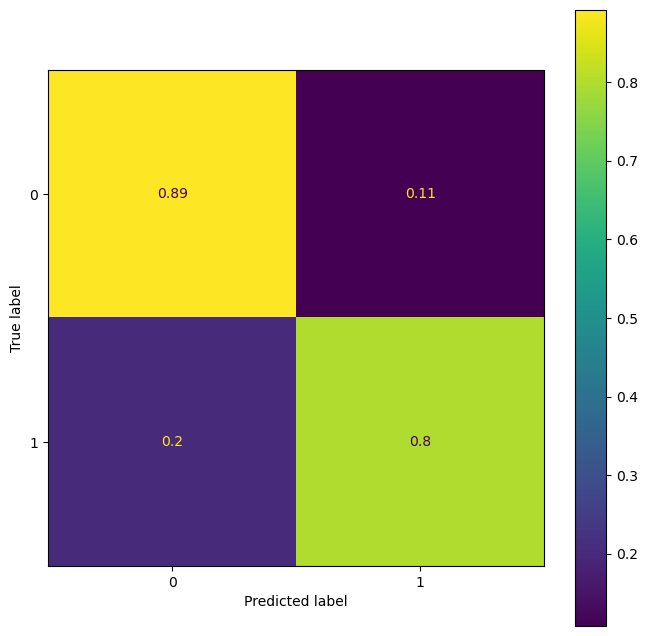

In [41]:
print("Test (rates):\n", confusion_matrix(y_test, y_pred_test_all, normalize='true'))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test_all, normalize='true')

In [42]:
auc_test_all = roc_auc_score(y_test, y_score_test_all)
print(f"AUC test (all features): {auc_test_all:.4f}")

AUC test (all features): 0.9521


In [43]:
fprs_test_all, tprs_test_all, _ = roc_curve(y_test, y_score_test_all)

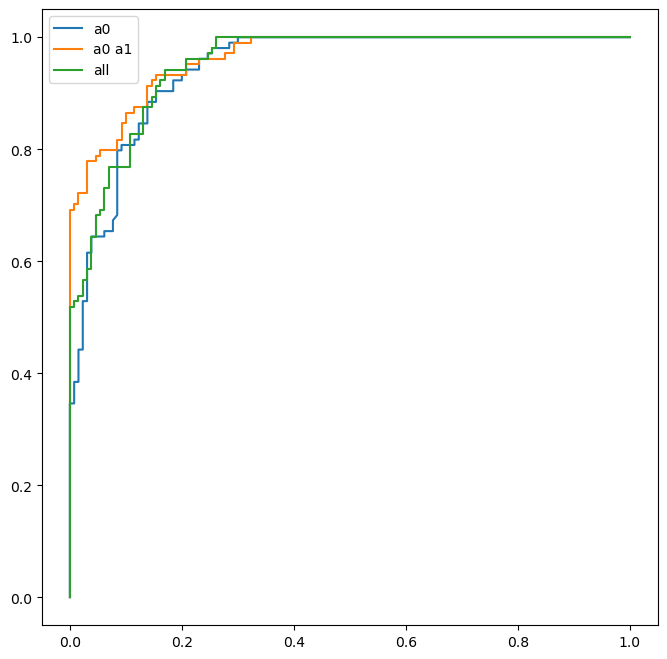

In [44]:
fig, ax = plt.subplots(figsize=(8,8))
ax.set_aspect(1.0)
plt.plot(fprs_test_a0, tprs_test_a0,label='a0');
plt.plot(fprs_test_a0a1, tprs_test_a0a1,label='a0 a1');
plt.plot(fprs_test_all, tprs_test_all,label='all');
plt.legend();

In [45]:
print(f"AUC test (a0):    {auc_test_a0:.4f}")
print(f"AUC test (a0+aX): {auc_test_a0a1:.4f}  (Δ vs a0: {auc_test_a0a1 - auc_test_a0:+.4f})")
print(f"AUC test (all):   {auc_test_all:.4f}  (Δ vs a0+aX: {auc_test_all - auc_test_a0a1:+.4f})")

AUC test (a0):    0.9443
AUC test (a0+aX): 0.9638  (Δ vs a0: +0.0195)
AUC test (all):   0.9521  (Δ vs a0+aX: -0.0117)



**Observation.** The 2-feature classifier (a0 + a1) achieves the highest test AUC of 0.964, outperforming both the single-feature (0.944) and all-features (0.963) models. Adding features a2 and a3 provides minimal benefit and slightly reduces performance, likely due to overfitting or noise from low-discriminative features.

**ROC Comparison.** The three ROC curves are nearly overlapping. The 2-feature model shows a slight edge in the low false-positive region (FPR < 0.1), where it achieves ~70% true positive rate with minimal false alarms - the most critical operating point for counterfeit detection.
